In [15]:
import matplotlib.pyplot as plt
def plot(corrected_df):
    # Create a figure and axes for the plot
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot XPN coordinates
    ax.scatter(corrected_df['XPN X'], corrected_df['XPN Y'], label='XPN', marker='o', color='blue')

    # Plot XPR coordinates
    ax.scatter(corrected_df['XPR X'], corrected_df['XPR Y'], label='XPR', marker='x', color='red')

    # Add labels and title
    ax.set_xlabel('X-axis')
    ax.set_ylabel('Y-axis')
    ax.set_title('XPN vs XPR Coordinates')
    ax.legend()
    ax.grid(True)

    # Show the plot
    plt.show()

In [16]:
import numpy as np
import pandas as pd
def correct_deviation_batch(xpn_coords, xpr_coords, htol_array):
    xpn = np.asarray(xpn_coords, dtype=float)
    xpr = np.asarray(xpr_coords, dtype=float)
    htol = np.asarray(htol_array, dtype=float).ravel()
    n = xpr.shape[0]
    assert htol.shape[0] == n, "HTol length mismatch"

    deltas = xpn - xpr
    orig_dev = np.linalg.norm(deltas, axis=1)

    # distances to move
    move_dist = np.maximum(orig_dev - htol, 0.0)

    # safe normalization
    direction = np.zeros_like(deltas)
    nz = orig_dev > 0
    direction[nz] = deltas[nz] / orig_dev[nz, None]

    corrected_xpr = xpr + direction * move_dist[:, None]

    final_dev = np.linalg.norm(xpn - corrected_xpr, axis=1)
    correction_magnitude = np.linalg.norm(corrected_xpr - xpr, axis=1)

    eps = 1e-9
    remarks = np.where(orig_dev <= htol + eps, "Within tolerance",
                       np.where(final_dev <= htol + eps, "Corrected", "Out of spec"))

    return corrected_xpr, orig_dev, final_dev, correction_magnitude, remarks

Index(['Point# (XPN)', 'XPN X', 'XPN Y', 'XPN Z', 'HTol', 'LTol', 'XPR X',
       'XPR Y', 'XPR Z', 'I', 'J', 'K', 'Deviation', 'Error',
       'Correction_Magnitude', 'Remarks'],
      dtype='object')


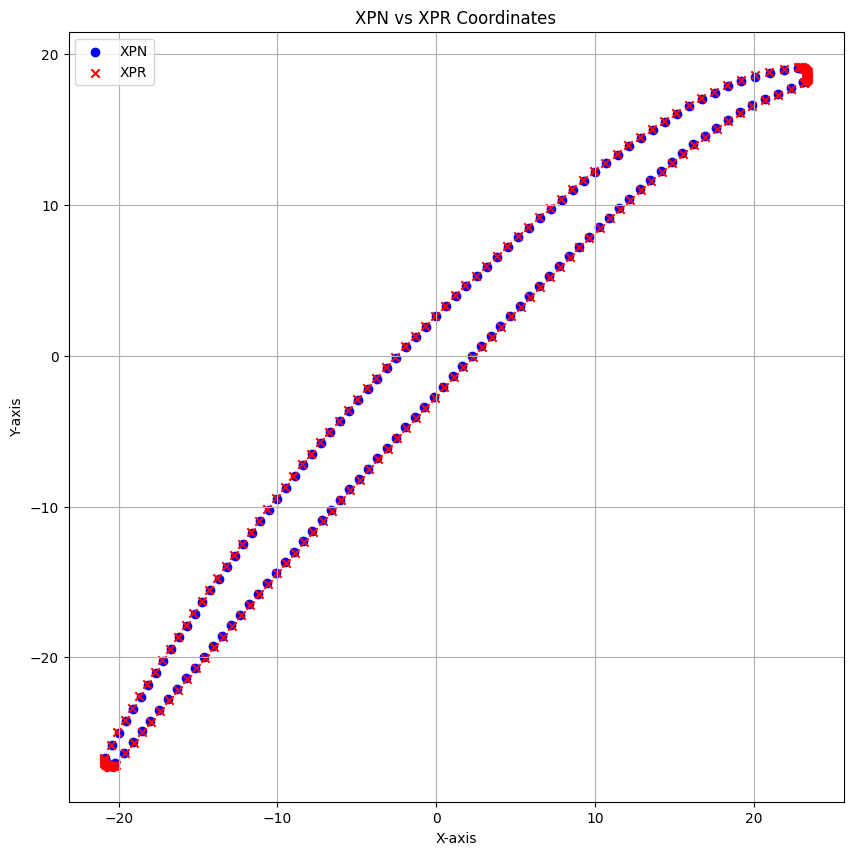

,Point# (XPN),XPN X,XPN Y,XPN Z,HTol,LTol,XPR X,XPR Y,XPR Z,I,J,K,Deviation,Error,Correction_Magnitude,Remarks
4,5.0,19.871,16.608,220.0,0.08,0.0,19.907,16.536,220.0,0.507,-0.862,0.000,0.08,0.0,0.754,Out of spec
6,7.0,18.345,15.651,220.0,0.08,0.0,18.395,15.589,220.0,0.555,-0.832,0.000,0.08,0.0,0.772,Out of spec
8,9.0,16.897,14.579,220.0,0.08,0.0,16.945,14.515,220.0,0.607,-0.795,0.000,0.08,0.0,0.775,Out of spec
13,14.0,13.475,11.652,220.0,0.08,0.0,13.522,11.587,220.0,0.682,-0.731,0.000,0.08,0.0,0.760,Out of spec
14,15.0,12.814,11.039,220.0,0.08,0.0,12.868,10.979,220.0,0.687,-0.726,0.000,0.08,0.0,0.760,Out of spec
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,163.0,23.323,18.806,220.0,0.08,0.0,23.402,18.801,220.0,1.000,-0.010,0.005,0.08,0.0,1.049,Out of spec
165,166.0,23.360,18.540,220.0,0.08,0.0,23.424,18.492,220.0,0.714,-0.700,0.000,0.08,0.0,0.878,Out of spec
166,167.0,23.339,18.452,220.0,0.08,0.0,23.382,18.384,220.0,0.544,-0.839,0.000,0.08,0.0,0.833,Out of spec
168,169.0,23.251,18.294,220.0,0.08,0.0,23.305,18.235,220.0,0.544,-0.839,0.000,0.08,0.0,0.761,Out of spec


In [17]:
import pandas as pd
df = pd.read_csv('SEC_A5_original.csv')
print(df.columns)
plot(df)
out_of_spec_df = df[df["Remarks"] == "Out of spec"]
out_of_spec_df

In [ ]:
import numpy as np
import pandas as pd
def correct_deviation_batch(xpn_coords, xpr_coords, htol_array):
    xpn = np.asarray(xpn_coords, dtype=float)
    xpr = np.asarray(xpr_coords, dtype=float)
    htol = np.asarray(htol_array, dtype=float).ravel()
    n = xpr.shape[0]
    assert htol.shape[0] == n, "HTol length mismatch"

    deltas = xpn - xpr
    orig_dev = np.linalg.norm(deltas, axis=1)

    # distances to move
    move_dist = np.maximum(orig_dev - htol, 0.0)

    # safe normalization
    direction = np.zeros_like(deltas)
    nz = orig_dev > 0
    direction[nz] = deltas[nz] / orig_dev[nz, None]

    corrected_xpr = xpr + direction * move_dist[:, None]

    final_dev = np.linalg.norm(xpn - corrected_xpr, axis=1)
    correction_magnitude = np.linalg.norm(corrected_xpr - xpr, axis=1)

    eps = 1e-9
    remarks = np.where(orig_dev <= htol + eps, "Within tolerance",
                       np.where(final_dev <= htol + eps, "Corrected", "Out of spec"))

    return corrected_xpr, orig_dev, final_dev, correction_magnitude, remarks


# === Usage with your dataframe ===
xpn_coords = df[["XPN X", "XPN Y", "XPN Z"]].to_numpy()
xpr_coords = df[["XPR X", "XPR Y", "XPR Z"]].to_numpy()
htol_array = np.asarray(df["HTol"], dtype=float)

corrected_xpr,orig_devs, final_deviation, correction_magnitude, remarks = correct_deviation_batch(
    xpn_coords, xpr_coords, htol_array
    )

# Update dataframe
corrected_df = df.copy()
corrected_df[["XPR X", "XPR Y", "XPR Z"]] = corrected_xpr
corrected_df["Deviation"] = final_deviation
corrected_df["Orig_Deviation"] = orig_devs
corrected_df["Correction_Magnitude"] = correction_magnitude
corrected_df["Remarks"] = remarks

# corrected_df = corrected_df.round(4)
corrected_df



,Point# (XPN),XPN X,XPN Y,XPN Z,HTol,LTol,XPR X,XPR Y,XPR Z,I,J,K,Deviation,Error,Correction_Magnitude,Remarks,Orig_Deviation
0,1.0,23.110,18.180,220.0,0.08,0.0,23.146000,18.109000,220.0,0.512,-0.859,0.0,0.079605,-0.0,0.000000,Within tolerance,0.079605
1,2.0,22.317,17.754,220.0,0.08,0.0,22.351975,17.682051,220.0,0.434,-0.901,0.0,0.080000,-0.0,0.000056,Corrected,0.080056
2,3.0,21.497,17.382,220.0,0.08,0.0,21.539000,17.314000,220.0,0.428,-0.904,0.0,0.079925,-0.0,0.000000,Within tolerance,0.079925
3,4.0,20.672,17.020,220.0,0.08,0.0,20.701000,16.946000,220.0,0.490,-0.872,0.0,0.079480,-0.0,0.000000,Within tolerance,0.079480
4,5.0,19.871,16.608,220.0,0.08,0.0,19.906777,16.536446,220.0,0.507,-0.862,0.0,0.080000,0.0,0.000498,Corrected,0.080498
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,167.0,23.339,18.452,220.0,0.08,0.0,23.381757,18.384385,220.0,0.544,-0.839,0.0,0.080000,0.0,0.000455,Corrected,0.080455
167,168.0,23.302,18.369,220.0,0.08,0.0,23.350000,18.305000,220.0,0.544,-0.839,0.0,0.080000,-0.0,0.000000,Within tolerance,0.080000
168,169.0,23.251,18.294,220.0,0.08,0.0,23.305000,18.235000,220.0,0.544,-0.839,0.0,0.079981,0.0,0.000000,Within tolerance,0.079981
169,170.0,23.186,18.231,220.0,0.08,0.0,23.213000,18.156000,220.0,0.512,-0.859,0.0,0.079712,0.0,0.000000,Within tolerance,0.079712


In [23]:
# Python
import numpy as np
import pandas as pd

# tolerance for float comparisons
tol = 1e-6

# build boolean mask where either X or Y differs beyond tolerance (handles NaN)
def col_changed(a, b, tol=tol):
    a_arr = np.asarray(a, dtype=float)
    b_arr = np.asarray(b, dtype=float)
    # treat NaNs as equal if both NaN, otherwise detect change
    both_nan = np.isnan(a_arr) & np.isnan(b_arr)
    close = np.isclose(a_arr, b_arr, atol=tol, equal_nan=False)
    return ~(close | both_nan)

mask_x = col_changed(df["XPR X"], corrected_df["XPR X"])
mask_y = col_changed(df["XPR Y"], corrected_df["XPR Y"])
mask = mask_x | mask_y

if not mask.any():
    print("No changes detected in XPR X / XPR Y (within tol).")
else:
    # build a concise before/after DataFrame and delta
    diff = pd.DataFrame({
        "XPR X_before": df.loc[mask, "XPR X"],
        "XPR X_after": corrected_df.loc[mask, "XPR X"].round(4),
        # "Δ XPR X": corrected_df.loc[mask, "XPR X"] - df.loc[mask, "XPR X"],
        "XPR Y_before": df.loc[mask, "XPR Y"],
        "XPR Y_after": corrected_df.loc[mask, "XPR Y"],
        # "Δ XPR Y": corrected_df.loc[mask, "XPR Y"] - df.loc[mask, "XPR Y"],
    })
    # print all changed rows (index shows original row number)
    print(f"Changed rows: {len(diff)}")
    print(diff)
    # if you only want rows 160-170:
    print("\nChanges in rows 160-170 (if any):")
    print(diff.loc[160:170])

Changed rows: 61
     XPR X_before  XPR X_after  XPR Y_before  XPR Y_after
4          19.907      19.9068        16.536    16.536446
7          17.655      17.6546        15.057    15.057664
12         14.183      14.1829        12.188    12.188225
13         13.522      13.5219        11.587    11.587172
14         12.868      12.8675        10.979    10.979536
..            ...          ...           ...          ...
148        16.695      16.6952        17.082    17.081554
149        17.499      17.4993        17.527    17.526459
157        23.015      23.0148        19.156    19.155429
161        23.355      23.3544        18.909    18.908806
166        23.382      23.3818        18.384    18.384385

[61 rows x 4 columns]

Changes in rows 160-170 (if any):
     XPR X_before  XPR X_after  XPR Y_before  XPR Y_after
161        23.355      23.3544        18.909    18.908806
166        23.382      23.3818        18.384    18.384385


In [ ]:
# run this cell right after you compute corrected_xpr, final_deviation, correction_magnitude, remarks

import numpy as np
idx = np.arange(160,170)
orig_devs = np.linalg.norm(xpn_coords - xpr_coords, axis=1)
correction_distances = np.maximum(orig_devs - htol_array, 0)
mags = correction_magnitude  # from your function
deltas = xpn_coords - xpr_coords

for i in idx:
    print(i,
          "orig_dev=", orig_devs[i],
          "htol=", float(htol_array[i]),
          "corr_dist=", float(correction_distances[i]),
          "corr_mag=", float(mags[i]),
          "moved_vec=", (corrected_xpr[i] - xpr_coords[i]).tolist(),
          "delta_dir=", (deltas[i]/(orig_devs[i] if orig_devs[i]>0 else 1)).tolist()
    )

In [ ]:
print(corrected_df.iloc[160:170])

plot(corrected_df)
new_df = df.copy()
new_df[["XPN X", "XPN Y", "XPN Z"]] = df[["XPR X", "XPR Y", "XPR Z"]]
plot(new_df)

